# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import boto3
from dotenv import load_dotenv

load_dotenv()

True

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [5]:
tracks = pd.read_parquet('tracks.parquet')
catalog_names = pd.read_parquet('catalog_names.parquet')
interactions = pd.read_parquet('interactions.parquet')

In [6]:
tracks.info()
display(tracks.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"


In [7]:
catalog_names.info()
display(catalog_names.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts


In [8]:
# 1. Выводим техническую информацию (она всегда будет текстовой)
interactions.info()

# 2. Создаем стилизованную таблицу и сразу выводим её на экран
# (Метод .style автоматически отображается красиво, display() здесь писать необязательно, но можно)
interactions.head(5).style.background_gradient(cmap='Blues')


<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17 00:00:00
1,0,589498,2,2022-07-19 00:00:00
2,0,590262,3,2022-07-21 00:00:00
3,0,590303,4,2022-07-22 00:00:00
4,0,590692,5,2022-07-22 00:00:00


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [9]:
print(tracks.isna().sum())
print(catalog_names.isna().sum())
print(interactions.isna().sum())

track_id    0
albums      0
artists     0
genres      0
dtype: int64
id      0
type    0
name    0
dtype: int64
user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64


<span style="color:green">В них  нет явных пропусков</span>.

In [10]:
tracks["track_id"].is_unique

True

<span style="color:green">Каждый идентификатор трека встречается в таблице строго один раз</span>

In [11]:
catalog_names["id"].is_unique
catalog_names[["id", "type"]].duplicated().sum()

0

<span style="color:green">Результат 0 означает, что в таблице нет ни одной повторяющейся пары «идентификатор + тип объекта». Каждая строчка описывает абсолютно уникальный объект каталога.</span>

In [12]:
interactions["user_id"].is_unique

False

<span style="color:green">Значение False здесь означает, что один и тот же пользователь (user_id) встречается в таблице несколько раз</span>

In [13]:
interactions["started_at"].min(), interactions["started_at"].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2022-12-31 00:00:00'))

In [14]:
interactions["started_at"].dt.month.value_counts().sort_index()

started_at
1      2409541
2      4533363
3      7691225
4     10230295
5     13613489
6     16266558
7     20188819
8     23919641
9     26953965
10    31810464
11    33968803
12    31043735
Name: count, dtype: int64

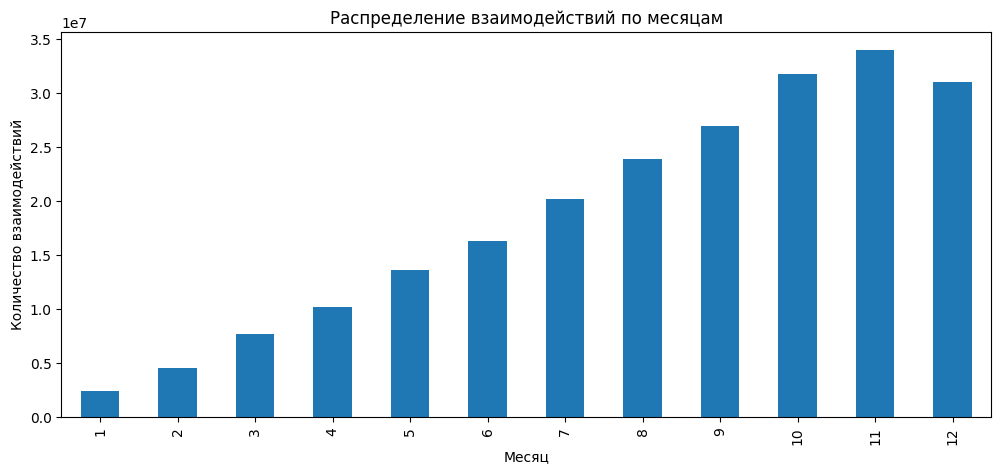

In [15]:
interactions["started_at"].dt.month.value_counts().sort_index().plot(
    kind="bar",
    figsize=(12, 5)
)

plt.xlabel("Месяц")
plt.ylabel("Количество взаимодействий")
plt.title("Распределение взаимодействий по месяцам")
plt.show()

In [16]:
users_by_month = (
    interactions
    .groupby(interactions["started_at"].dt.month)["user_id"]
    .nunique()
)

In [17]:
interactions_by_month = (
    interactions["started_at"]
    .dt.month
    .value_counts()
    .sort_index()
)

interactions_per_user = interactions_by_month / users_by_month

monthly_stats = pd.DataFrame({
    "interactions": interactions_by_month,
    "users": users_by_month,
    "interactions_per_user": interactions_per_user
})

monthly_stats.index.name = "month"

monthly_stats

,interactions,users,interactions_per_user
month,,,
1,2409541,126224,19.089405
2,4533363,227852,19.896086
3,7691225,344333,22.336590
4,10230295,454378,22.514944
5,13613489,569813,23.891152
6,16266558,676467,24.046344
7,20188819,788369,25.608337
8,23919641,892539,26.799547
9,26953965,979781,27.510194


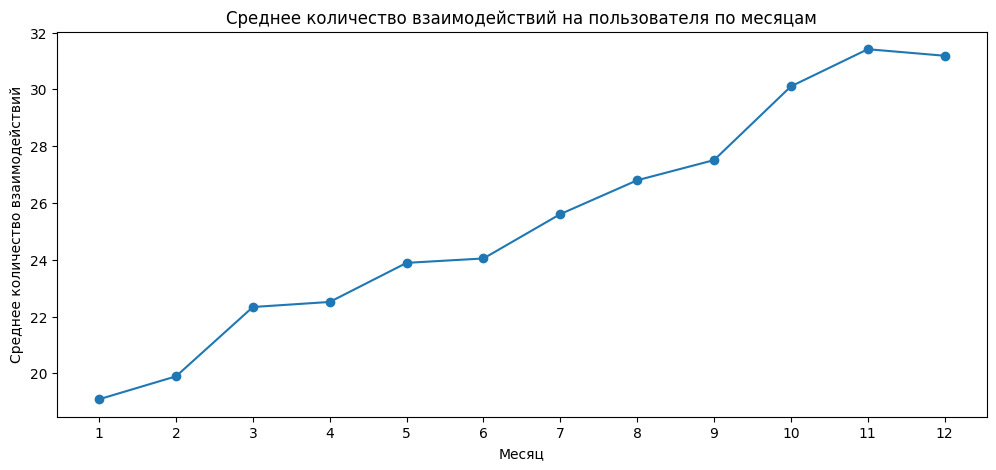

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_stats.index,
    monthly_stats["interactions_per_user"],
    marker="o"
)

plt.xlabel("Месяц")
plt.ylabel("Среднее количество взаимодействий")
plt.title("Среднее количество взаимодействий на пользователя по месяцам")
plt.xticks(monthly_stats.index)

plt.show()

In [19]:
albums = tracks[
    tracks['albums'].notna()
][['track_id', 'albums']].explode('albums')

albums = albums.merge(
    catalog_names[catalog_names['type'] == 'album'],
    left_on='albums',
    right_on='id',
    how='left'
)

unknown_albums = albums[
    albums['name'].isna()
]

print('Неизвестных ID альбомов:', unknown_albums['albums'].nunique())
print('Треков с неизвестными альбомами:', unknown_albums['track_id'].nunique())

display(unknown_albums)

Неизвестных ID альбомов: 0
Треков с неизвестными альбомами: 18


,track_id,albums,id,type,name
1130893,20200372,NaN,NaN,NaN,NaN
1130900,20200380,NaN,NaN,NaN,NaN
1134921,20305116,NaN,NaN,NaN,NaN
1134928,20305121,NaN,NaN,NaN,NaN
1167958,20756854,NaN,NaN,NaN,NaN
1187442,21196099,NaN,NaN,NaN,NaN
1187449,21196103,NaN,NaN,NaN,NaN
1187452,21196105,NaN,NaN,NaN,NaN
1187455,21196107,NaN,NaN,NaN,NaN
1187459,21196109,NaN,NaN,NaN,NaN


In [20]:
tracks = tracks.dropna(subset=['albums'])

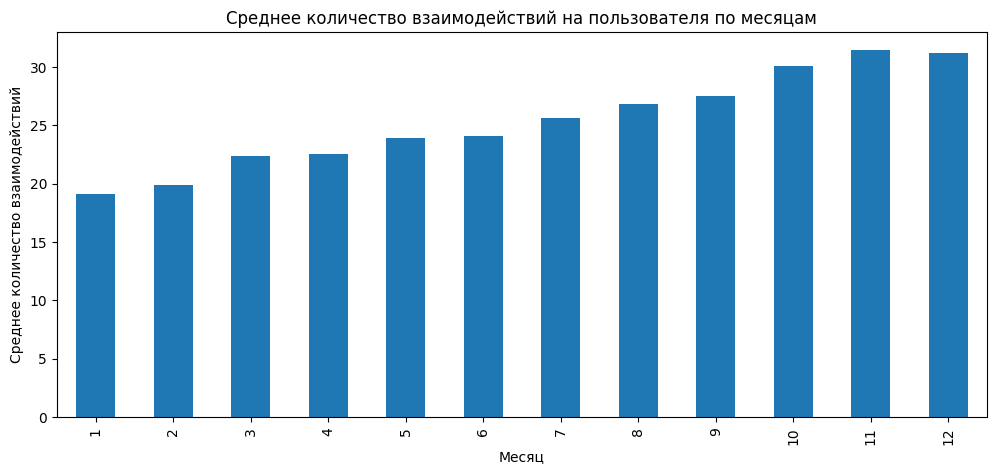

In [21]:
interactions_per_user.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.xlabel("Месяц")
plt.ylabel("Среднее количество взаимодействий")
plt.title("Среднее количество взаимодействий на пользователя по месяцам")
plt.show()

В течение 2022 года наблюдается выраженный рост количества взаимодействий пользователей с треками. Минимальное количество взаимодействий зафиксировано в январе, максимальное — в ноябре. В декабре наблюдается небольшое снижение активности относительно ноября.

# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

### Выводы

По результатам первичного знакомства с данными явных критических проблем не обнаружено.

- Данные успешно загружены, типы признаков выглядят корректно.
- В таблице `tracks` идентификатор `track_id` уникален, пропуски отсутствуют.
- В таблице `catalog_names` поле `id` само по себе не уникально, однако комбинация `id` и `type` уникальна. Следовательно, повторение `id` связано с использованием идентификаторов для разных типов объектов каталога и не является проблемой качества данных.
- В таблице `interactions` `user_id` не уникален, что является ожидаемым поведением, поскольку один пользователь может совершать множество взаимодействий.
- Данные о взаимодействиях охватывают весь 2022 год.
- Количество взаимодействий и число активных пользователей увеличиваются в течение года и достигают максимума в ноябре.
- Среднее количество взаимодействий на одного активного пользователя также растёт примерно с 19 в январе до 31 в ноябре.

Корректирующие действия на данном этапе не потребовались.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [22]:
tracks_per_user = (
    interactions
    .groupby("user_id")["track_id"]
    .nunique()
)

tracks_per_user.head()

user_id
0     26
1     36
2     14
3     33
4    256
Name: track_id, dtype: int64

In [23]:
tracks_per_user.describe()

count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
max      1.663700e+04
Name: track_id, dtype: float64

In [24]:
tracks_per_user.quantile([0.5, 0.75, 0.9, 0.95, 0.99])

0.50      55.0
0.75     154.0
0.90     389.0
0.95     650.0
0.99    1576.0
Name: track_id, dtype: float64

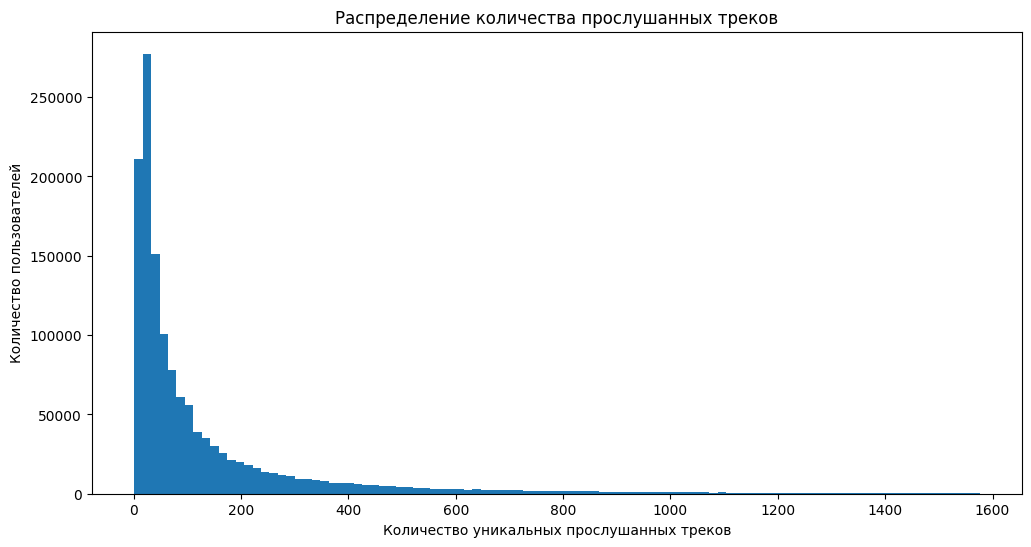

In [25]:
q99 = tracks_per_user.quantile(0.99)

plt.figure(figsize=(12, 6))

plt.hist(
    tracks_per_user[tracks_per_user <= q99],
    bins=100
)

plt.xlabel("Количество уникальных прослушанных треков")
plt.ylabel("Количество пользователей")
plt.title("Распределение количества прослушанных треков")
plt.show()

In [26]:
tracks_per_user.quantile([0.90, 0.95, 0.99])

0.90     389.0
0.95     650.0
0.99    1576.0
Name: track_id, dtype: float64

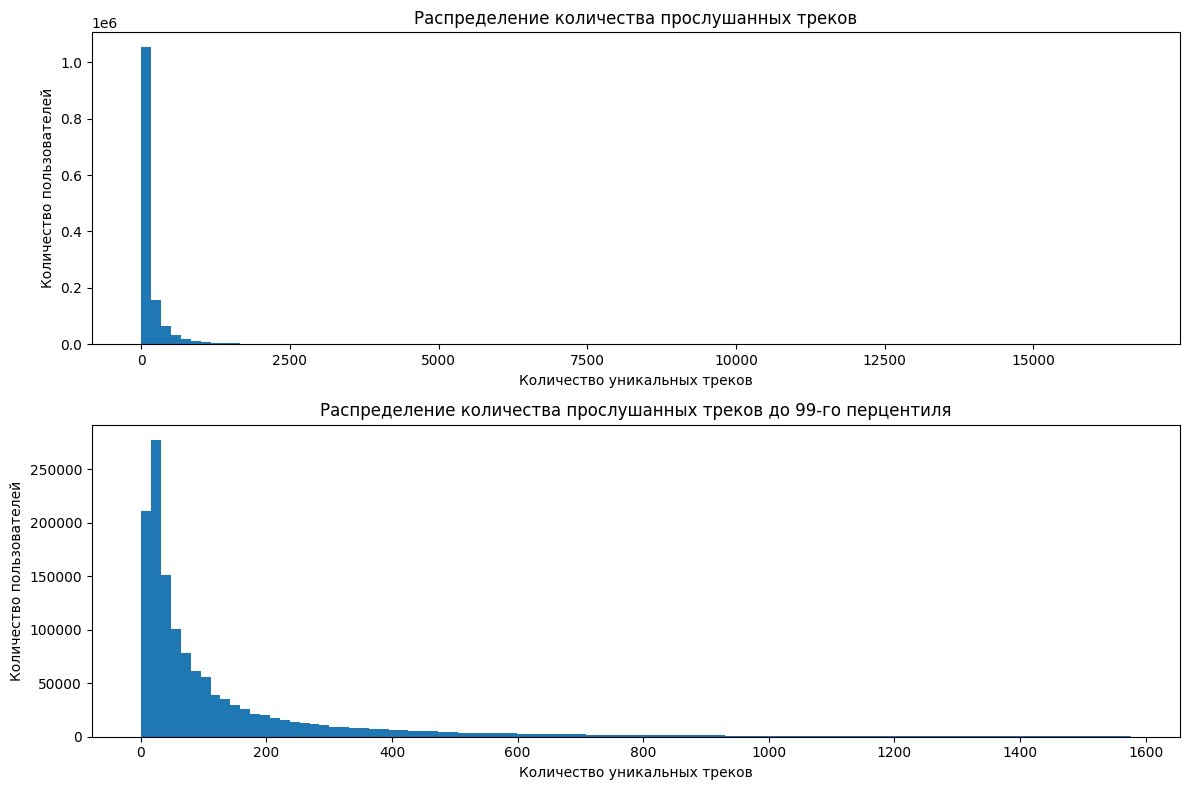

In [27]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Полное распределение
axs[0].hist(tracks_per_user, bins=100)
axs[0].set_title("Распределение количества прослушанных треков")
axs[0].set_xlabel("Количество уникальных треков")
axs[0].set_ylabel("Количество пользователей")

# Основная часть распределения — до 99-го перцентиля
q99 = tracks_per_user.quantile(0.99)

axs[1].hist(
    tracks_per_user[tracks_per_user <= q99],
    bins=100
)
axs[1].set_title("Распределение количества прослушанных треков до 99-го перцентиля")
axs[1].set_xlabel("Количество уникальных треков")
axs[1].set_ylabel("Количество пользователей")

fig.tight_layout()
plt.show()

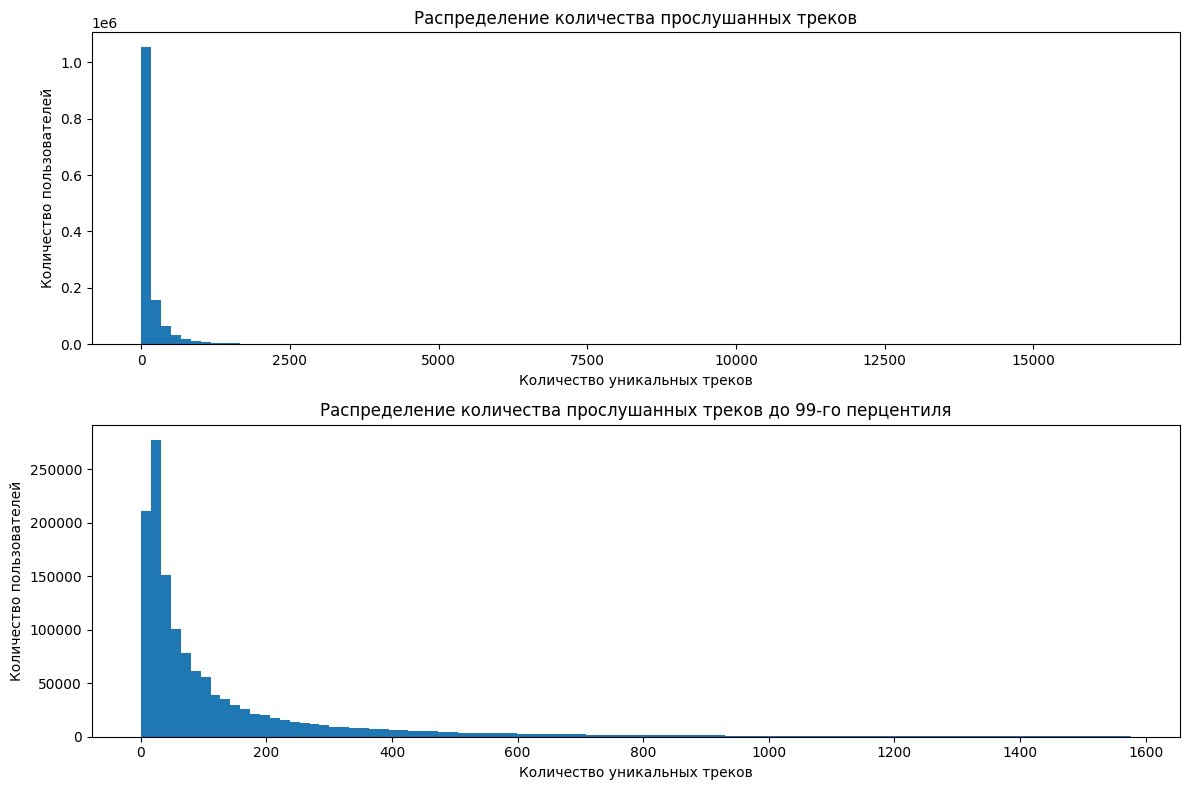

In [28]:
q99 = tracks_per_user.quantile(0.99)

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Полное распределение
axs[0].hist(tracks_per_user, bins=100)
axs[0].set_title("Распределение количества прослушанных треков")
axs[0].set_xlabel("Количество уникальных треков")
axs[0].set_ylabel("Количество пользователей")

# Основная часть распределения — до 99-го перцентиля
axs[1].hist(
    tracks_per_user[tracks_per_user <= q99],
    bins=100
)
axs[1].set_title("Распределение количества прослушанных треков до 99-го перцентиля")
axs[1].set_xlabel("Количество уникальных треков")
axs[1].set_ylabel("Количество пользователей")

fig.tight_layout()
plt.show()

Распределение количества уникальных прослушанных треков имеет выраженную правостороннюю асимметрию. Медианное значение составляет 55 треков, тогда как среднее — около 162. При этом 90% пользователей прослушали не более 389 треков, 95% — не более 650, а 99% — не более 1576. Максимальное значение составляет 16 637 треков, что указывает на наличие небольшой группы очень активных пользователей.

Наиболее популярные треки

In [29]:
popular_tracks = (
    interactions["track_id"]
    .value_counts()
    .head(20)
)

popular_tracks

track_id
53404       111062
33311009    106921
178529      101924
35505245     99490
65851540     86670
24692821     86246
32947997     85886
51241318     85244
795836       85042
45499814     84748
60292250     84471
6705392      82483
39257277     81978
29544272     81057
37384        80153
51516485     78370
2758009      78181
47627256     76052
328683       75686
57921154     74733
Name: count, dtype: int64

In [30]:
popular_tracks = (
    interactions["track_id"]
    .value_counts()
    .head(20)
    .reset_index()
)

popular_tracks.columns = ["track_id", "interactions_count"]

popular_tracks

,track_id,interactions_count
0,53404,111062
1,33311009,106921
2,178529,101924
3,35505245,99490
4,65851540,86670
5,24692821,86246
6,32947997,85886
7,51241318,85244
8,795836,85042
9,45499814,84748


In [ ]:
# top_tracks = popular_tracks.sort_values(
#     "interactions_count",
#     ascending=True
# )

# plt.figure(figsize=(12, 8))

# plt.barh(
#     top_tracks["name"],
#     top_tracks["interactions_count"]
# )

# plt.xlabel("Количество взаимодействий")
# plt.ylabel("Трек")
# plt.title("20 наиболее популярных треков")

# plt.show()

KeyError: 'name'

<Figure size 1200x800 with 0 Axes>

In [32]:
catalog_names["type"].value_counts()

type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64

In [33]:
track_names = (
    catalog_names[catalog_names["type"] == "track"]
    [["id", "name"]]
    .rename(columns={"id": "track_id"})
)

In [34]:
popular_tracks = popular_tracks.merge(
    track_names,
    on="track_id",
    how="left"
)

popular_tracks

,track_id,interactions_count,name
0,53404,111062,Smells Like Teen Spirit
1,33311009,106921,Believer
2,178529,101924,Numb
3,35505245,99490,I Got Love
4,65851540,86670,Юность
5,24692821,86246,Way Down We Go
6,32947997,85886,Shape of You
7,51241318,85244,In The End
8,795836,85042,Shape Of My Heart
9,45499814,84748,Life


Наиболее популярные жанры

In [35]:
# Сколько взаимодействий приходится на каждый трек
track_popularity = (
    interactions["track_id"]
    .value_counts()
    .rename_axis("track_id")
    .reset_index(name="interactions_count")
)

track_popularity.head()

,track_id,interactions_count
0,53404,111062
1,33311009,106921
2,178529,101924
3,35505245,99490
4,65851540,86670


In [36]:
track_genres = tracks[
    ["track_id", "genres"]
].merge(
    track_popularity,
    on="track_id",
    how="left"
)

track_genres.head()

,track_id,genres,interactions_count
0,26,"[11, 21]",5
1,38,"[11, 21]",8
2,135,[11],16
3,136,[11],7
4,138,[11],17


In [37]:
track_genres = track_genres.explode("genres")

In [38]:
popular_genres = (
    track_genres
    .groupby("genres", as_index=False)["interactions_count"]
    .sum()
    .sort_values("interactions_count", ascending=False)
)

popular_genres.head(20)

,genres,interactions_count
10,11,55578312
70,75,37799821
95,102,31092013
19,20,26626241
2,3,25303695
63,68,20120981
15,16,16291557
1,2,13166147
13,14,12772644
42,47,12437375


In [39]:
genre_names = (
    catalog_names[catalog_names["type"] == "genre"]
    [["id", "name"]]
    .rename(columns={"id": "genres"})
)

popular_genres = popular_genres.merge(
    genre_names,
    on="genres",
    how="left"
)

popular_genres.head(20)

,genres,interactions_count,name
0,11,55578312,pop
1,75,37799821,rap
2,102,31092013,allrock
3,20,26626241,ruspop
4,3,25303695,rusrap
5,68,20120981,electronics
6,16,16291557,dance
7,2,13166147,rusrock
8,14,12772644,rock
9,47,12437375,metal


In [40]:
top_genres = popular_genres.head(20)

top_genres

,genres,interactions_count,name
0,11,55578312,pop
1,75,37799821,rap
2,102,31092013,allrock
3,20,26626241,ruspop
4,3,25303695,rusrap
5,68,20120981,electronics
6,16,16291557,dance
7,2,13166147,rusrock
8,14,12772644,rock
9,47,12437375,metal


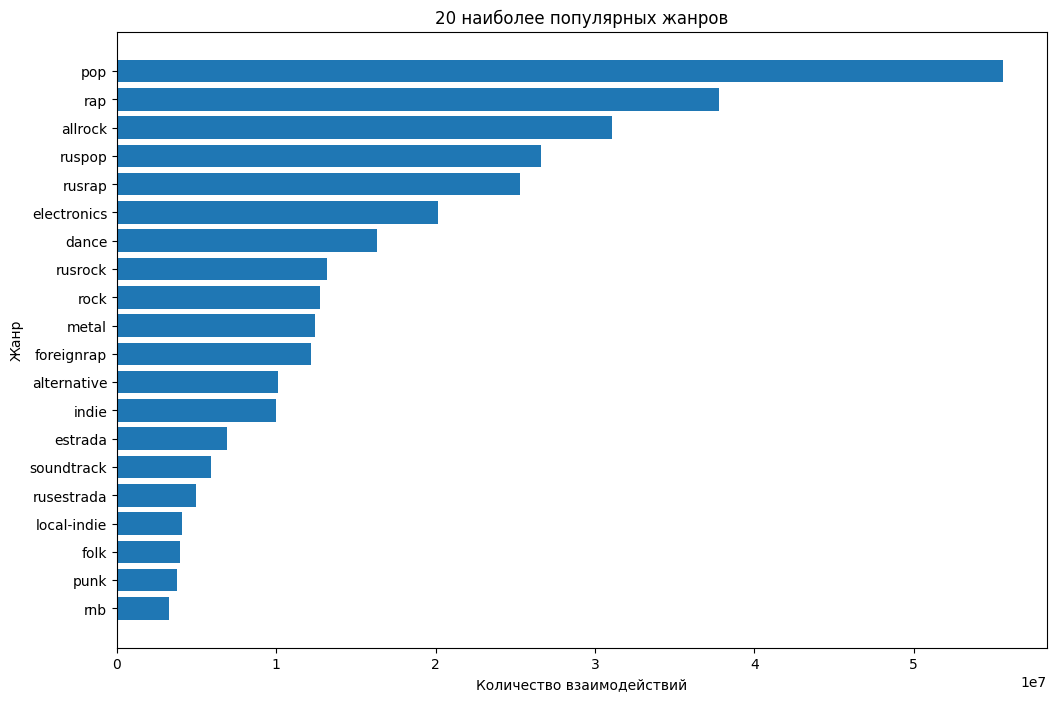

In [41]:
plt.figure(figsize=(12, 8))

plt.barh(
    top_genres["name"],
    top_genres["interactions_count"]
)

plt.xlabel("Количество взаимодействий")
plt.ylabel("Жанр")
plt.title("20 наиболее популярных жанров")

plt.gca().invert_yaxis()

plt.show()

### Вывод

Распределение популярности жанров неравномерное.

Наиболее популярным жанром является `pop`, далее идут `rap`, `allrock`, `ruspop` и `rusrap`. После первых нескольких жанров количество взаимодействий заметно снижается.

Таким образом, основная часть прослушиваний сосредоточена в относительно небольшом количестве популярных жанров, тогда как остальные жанры имеют существенно меньшую аудиторию.

Треки, которые никто не прослушал

In [42]:
# Треки, которые ни разу не встречались во взаимодействиях
unlistened_tracks = tracks[
    ~tracks["track_id"].isin(track_popularity["track_id"])
]

unlistened_tracks.head()

,track_id,albums,artists,genres


In [43]:
len(unlistened_tracks)

0

### Треки, которые никто не прослушал

Треков без единого взаимодействия не обнаружено.

Все треки из каталога `tracks` хотя бы один раз встречаются в истории взаимодействий пользователей. Следовательно, в данных отсутствует проблема холодного старта для объектов в части полностью непрослушанных треков.

# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [44]:
events = interactions.copy()

# 1. Ужимаем ID пользователей и треков (int32 хватает для значений до 2 миллиардов)
events['user_id'] = events['user_id'].astype('int32')
events['track_id'] = events['track_id'].astype('int32')

# 2. Если track_seq — это порядковый номер трека в сессии (небольшие числа), переводим в int16
events['track_seq'] = events['track_seq'].astype('int16')

# 3. Переводим временную метку из тяжелой строки (object) в эффективный datetime64
events['started_at'] = pd.to_datetime(events['started_at'])

# Проверяем, сколько теперь весит датафрейм в памяти
events.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [45]:
interactions.to_parquet(
    "events.parquet",
    index=False
)

In [ ]:
tracks.to_parquet(
    "items.parquet",
    index=False
)

In [ ]:
s3 = boto3.client(
    "s3",
    endpoint_url="https://storage.yandexcloud.net",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
)


In [ ]:

bucket_name = os.getenv("S3_BUCKET_NAME")

s3.upload_file(
    "items.parquet",
    bucket_name,
    "recsys/data/items.parquet"
)

s3.upload_file(
    "events.parquet",
    bucket_name,
    "recsys/data/events.parquet"
)

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [46]:
import gc

# Закрываем все графики matplotlib
plt.close("all")

# Удаляем крупные DataFrame и промежуточные результаты,
# которые больше не понадобятся после сохранения в parquet/S3
variables_to_delete = [
    "tracks",
    "catalog_names",
    "interactions",
    "events",
    "albums",
    "unknown_albums",
    "tracks_per_user",
    "monthly_stats",
    "users_by_month",
    "interactions_by_month",
    "interactions_per_user",
    "popular_tracks",
    "top_tracks",
    "track_names",
    "track_popularity",
    "track_genres",
    "popular_genres",
    "genre_names",
    "top_genres",
    "unlistened_tracks",
]

for var in variables_to_delete:
    globals().pop(var, None)

# Запускаем сборщик мусора Python
gc.collect()

print("Память очищена")

Память очищена


команда htop выводит колличесвто оперативной памяти 

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [47]:
# Загружаем сохранённые данные
items = pd.read_parquet("items.parquet")
events = pd.read_parquet("events.parquet")

# Проверяем размер данных
print("items:", items.shape)
print("events:", events.shape)

items: (1000000, 4)
events: (222629898, 4)


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [48]:
# Дата разделения данных
split_date = pd.Timestamp("2022-12-16")

# Обучающая выборка:
# все взаимодействия ДО 16 декабря 2022 года, не включая эту дату
train = events[
    events["started_at"] < split_date
].copy()

# Тестовая выборка:
# взаимодействия начиная с 16 декабря 2022 года
test = events[
    events["started_at"] >= split_date
].copy()

# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [49]:
TOP_N = 100

top_popular = (
    train
    .groupby("track_id", as_index=False)
    .size()
    .rename(columns={"size": "score"})
    .sort_values("score", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

top_popular["rank"] = range(1, len(top_popular) + 1)



In [51]:
catalog_names = pd.read_parquet('catalog_names.parquet')

track_names = (
    catalog_names[catalog_names["type"] == "track"]
    [["id", "name"]]
    .rename(columns={
        "id": "track_id",
        "name": "track_name"
    })
)

top_popular = top_popular.merge(
    track_names,
    on="track_id",
    how="left"
)

In [52]:
top_popular = top_popular.merge(
    items[["track_id", "genres"]],
    on="track_id",
    how="left"
)

In [53]:
top_popular.head(4)

,track_id,score,rank,track_name,genres
0,53404,110026,1,Smells Like Teen Spirit,"[13, 14, 102]"
1,33311009,101076,2,Believer,"[14, 102]"
2,178529,100866,3,Numb,"[41, 47]"
3,35505245,95523,4,I Got Love,"[3, 75]"


In [ ]:
# Сохраняем рекомендации локально
top_popular.to_parquet(
    "top_popular.parquet",
    index=False
)

In [ ]:
bucket_name = os.getenv("S3_BUCKET_NAME")

s3.upload_file(
    "top_popular.parquet",
    bucket_name,
    "recsys/recommendations/top_popular.parquet"
)

print("Файл top_popular.parquet успешно загружен в S3")

Файл top_popular.parquet успешно загружен в S3


# Персональные

Рассчитаем персональные рекомендации.

In [ ]:
import gc
import sklearn.preprocessing

# --------------------------------------------------
# Удаляем результаты предыдущего расчёта
# --------------------------------------------------

for var in [
    "top_popular",
    "track_names",
]:
    globals().pop(var, None)

gc.collect()


# --------------------------------------------------
# Не создаём дополнительные копии train/test
# --------------------------------------------------

events_train = train
events_test = test

del train
del test

gc.collect()


# --------------------------------------------------
# Переименовываем track_id -> item_id
# --------------------------------------------------

events_train = events_train.rename(
    columns={"track_id": "item_id"}
)

events_test = events_test.rename(
    columns={"track_id": "item_id"}
)

items = items.rename(
    columns={"track_id": "item_id"}
)


# --------------------------------------------------
# Создаём энкодеры
# --------------------------------------------------

user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events["user_id"])

item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items["item_id"])


# --------------------------------------------------
# Полный events больше не нужен
# --------------------------------------------------

del events
gc.collect()


# --------------------------------------------------
# Кодируем ID
# --------------------------------------------------

events_train["user_id_enc"] = user_encoder.transform(
    events_train["user_id"]
)

events_test["user_id_enc"] = user_encoder.transform(
    events_test["user_id"]
)

items["item_id_enc"] = item_encoder.transform(
    items["item_id"]
)

events_train["item_id_enc"] = item_encoder.transform(
    events_train["item_id"]
)

events_test["item_id_enc"] = item_encoder.transform(
    events_test["item_id"]
)


# --------------------------------------------------
# Оставляем только необходимые для ALS колонки
# --------------------------------------------------

events_train = events_train[
    ["user_id", "item_id", "user_id_enc", "item_id_enc"]
].copy()

events_test = events_test[
    ["user_id", "item_id", "user_id_enc", "item_id_enc"]
].copy()

gc.collect()

print("Память подготовлена для обучения ALS")

NameError: name 'train' is not defined

In [54]:
# Чтобы соответствовать дальнейшему шаблону
events_train = train.copy()
events_test = test.copy()

# В рекомендательной системе будем называть трек item
items = items.rename(columns={"track_id": "item_id"})
events_train = events_train.rename(columns={"track_id": "item_id"})
events_test = events_test.rename(columns={"track_id": "item_id"})

In [55]:
import scipy
import sklearn.preprocessing

# Перекодируем идентификаторы пользователей:
# из исходных ID в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events["user_id"])

events_train["user_id_enc"] = user_encoder.transform(
    events_train["user_id"]
)

events_test["user_id_enc"] = user_encoder.transform(
    events_test["user_id"]
)

# Перекодируем идентификаторы объектов
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items["item_id"])

items["item_id_enc"] = item_encoder.transform(
    items["item_id"]
)

events_train["item_id_enc"] = item_encoder.transform(
    events_train["item_id"]
)

events_test["item_id_enc"] = item_encoder.transform(
    events_test["item_id"]
)

In [57]:
import sys
import pandas as pd
import numpy as np
import scipy.sparse

memory_stats = []

# Создаём снимок списка переменных,
# чтобы globals() не менялся во время обхода
for name, obj in list(globals().items()):
    if name.startswith("_"):
        continue

    try:
        # Pandas DataFrame
        if isinstance(obj, pd.DataFrame):
            size = obj.memory_usage(deep=True).sum()

        # Pandas Series
        elif isinstance(obj, pd.Series):
            size = obj.memory_usage(deep=True)

        # NumPy array
        elif isinstance(obj, np.ndarray):
            size = obj.nbytes

        # Sparse-матрицы scipy (важно для ALS)
        elif scipy.sparse.issparse(obj):
            size = (
                obj.data.nbytes
                + obj.indices.nbytes
                + obj.indptr.nbytes
            )

        # Остальные Python-объекты
        else:
            size = sys.getsizeof(obj)

        memory_stats.append(
            (name, type(obj).__name__, size)
        )

    except Exception:
        pass


memory_df = pd.DataFrame(
    memory_stats,
    columns=["variable", "type", "bytes"]
)

memory_df["MB"] = memory_df["bytes"] / 1024**2
memory_df["GB"] = memory_df["bytes"] / 1024**3

memory_df = (
    memory_df
    .sort_values("bytes", ascending=False)
    .reset_index(drop=True)
)

memory_df.head(30)

,variable,type,bytes,MB,GB
0,events_train,DataFrame,8766712584,8360.588631,8.164637e+00
1,train,DataFrame,5427012552,5175.602486,5.054299e+00
2,events,DataFrame,4007338292,3821.695606,3.732125e+00
3,events_test,DataFrame,583743132,556.700832,5.436532e-01
4,items,DataFrame,376000128,358.581665,3.501774e-01
5,test,DataFrame,361364796,344.624325,3.365472e-01
6,catalog_names,DataFrame,276519483,263.709529,2.575288e-01
7,track_names,DataFrame,100253450,95.609140,9.336830e-02
8,top_popular,DataFrame,22394,0.021357,2.085604e-05
9,Out,dict,1176,0.001122,1.095235e-06


# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.